In [1]:
import sqlite3

In [2]:
import random
import datetime
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Step 1: Connect to SQLite DB (or create it)
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [12]:
# Step 2: Create sales table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL,
    date TEXT
)
""")

In [13]:
# Step 3: Generate and insert 500 random sales records
products = ["Laptop", "Mouse", "Keyboard", "Monitor", "Printer",
            "USB Cable", "Webcam", "Speaker", "Router", "Headphones"]

for _ in range(500):
    product = random.choice(products)
    quantity = random.randint(1, 20)
    price = round(random.uniform(10.0, 500.0), 2)
    sale_date = datetime.datetime(2024, 1, 1) + datetime.timedelta(days=random.randint(0, 365))
    
    cursor.execute("""
        INSERT INTO sales (product, quantity, price, date)
        VALUES (?, ?, ?, ?)
    """, (product, quantity, price, sale_date.strftime("%Y-%m-%d")))

conn.commit()

In [14]:
# Step 4: Run SQL query to get total quantity and revenue per product
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    ROUND(SUM(quantity * price), 2) AS revenue 
FROM sales 
GROUP BY product
ORDER BY revenue DESC
"""

Sales Summary:

      product  total_qty    revenue
0     Monitor       2254  624297.20
1      Router       2319  613386.38
2   USB Cable       2212  590731.70
3     Printer       2157  573639.21
4      Laptop       2084  565799.76
5  Headphones       2207  563435.47
6      Webcam       2156  515490.84
7    Keyboard       1962  507150.05
8       Mouse       1918  500296.91
9     Speaker       1965  493627.25


<Figure size 1000x600 with 0 Axes>

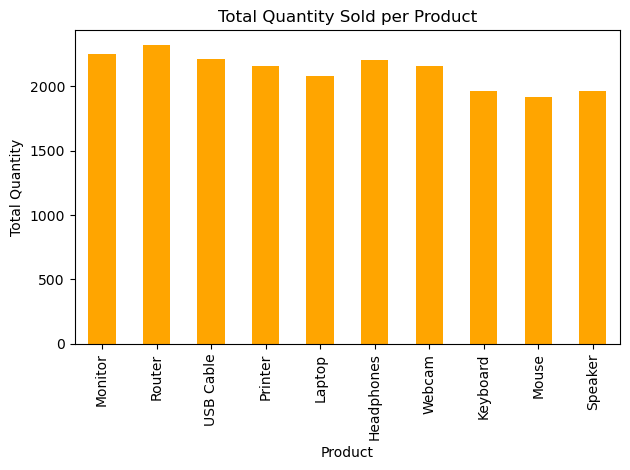

<Figure size 1000x600 with 0 Axes>

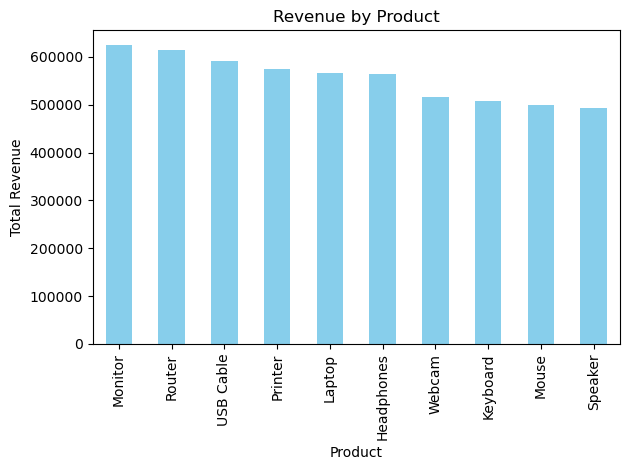

In [15]:
# Step 5: Load into pandas
df = pd.read_sql_query(query, conn)
print("Sales Summary:\n")
print(df)

# Step 6: Plot bar chart for revenue by product
plt.figure(figsize=(10, 6))
df.plot(kind='bar', x='product', y='total_qty', legend=False, color='orange')
plt.title("Total Quantity Sold per Product")
plt.xlabel("Product")
plt.ylabel("Total Quantity")
plt.tight_layout()
plt.savefig("total_quantity_chart.png")  # Optional: Save chart
plt.show()

plt.figure(figsize=(10, 6))
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Save chart as PNG
plt.show()

# Close DB connection